# Tetouan City Power Consumption — Data Exploration

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
sys.path.append('.')
from config import *

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.set_index('DateTime').sort_index()
df.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
DateTime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


## 2. Missing Values

In [3]:
print(df.isnull().sum())

Temperature                 0
Humidity                    0
Wind Speed                  0
general diffuse flows       0
diffuse flows               0
Zone 1 Power Consumption    0
Zone 2 Power Consumption    0
Zone 3 Power Consumption    0
dtype: int64


## 3. Descriptive Statistics

In [4]:
df.describe().round(2)

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
count,52416.00,52416.00,52416.00,52416.00,52416.00,52416.00,52416.00,52416.00
mean,18.81,68.26,1.96,182.70,75.03,32344.97,21042.51,17835.41
std,5.82,15.55,2.35,264.40,124.21,7130.56,5201.47,6622.17
min,3.25,11.34,0.05,0.00,0.01,13895.70,8560.08,5935.17
25%,14.41,58.31,0.08,0.06,0.12,26310.67,16980.77,13129.33
50%,18.78,69.86,0.09,5.04,4.46,32265.92,20823.17,16415.12
75%,22.89,81.40,4.92,319.60,101.00,37309.02,24713.72,21624.10
max,40.01,94.80,6.48,1163.00,936.00,52204.40,37408.86,47598.33


## 4. Wind Speed Anomaly

In [5]:
df['Wind Speed'].value_counts().head(20)

Wind Speed
0.082    2291
0.083    1979
0.084    1831
0.081    1804
0.085    1513
0.080    1502
0.073    1485
4.919    1430
4.916    1375
0.072    1369
0.071    1358
4.918    1353
4.917    1347
4.920    1342
0.070    1308
0.079    1203
0.086    1158
4.921    1157
0.069    1149
0.074    1098
Name: count, dtype: int64

## 5. Train / Test Split

In [6]:
train = df[df.index < SPLIT_DATE]
test  = df[df.index >= SPLIT_DATE]

print(f'Train: {len(train):,}  ({train.index.min().date()} → {train.index.max().date()})')
print(f'Test:  {len(test):,}  ({test.index.min().date()} → {test.index.max().date()})')

Train: 43,776  (2017-01-01 → 2017-10-31)
Test:  8,640  (2017-11-01 → 2017-12-30)


## 6. Feature Distributions

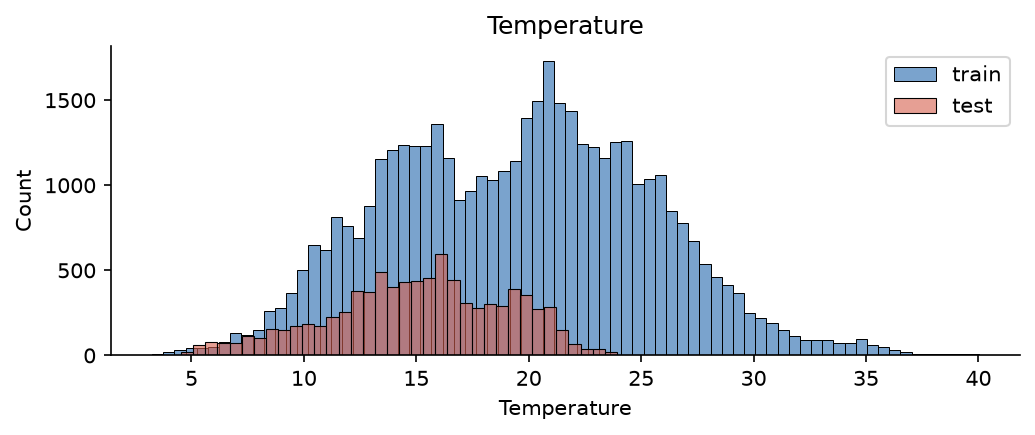

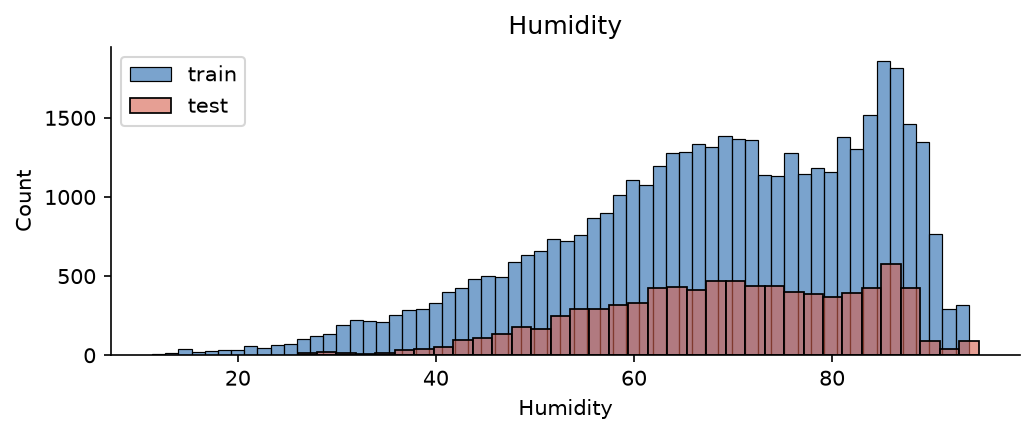

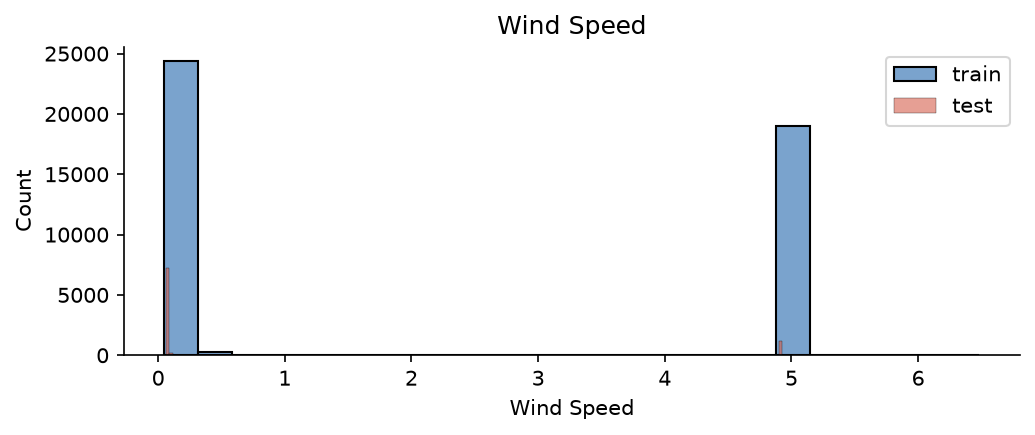

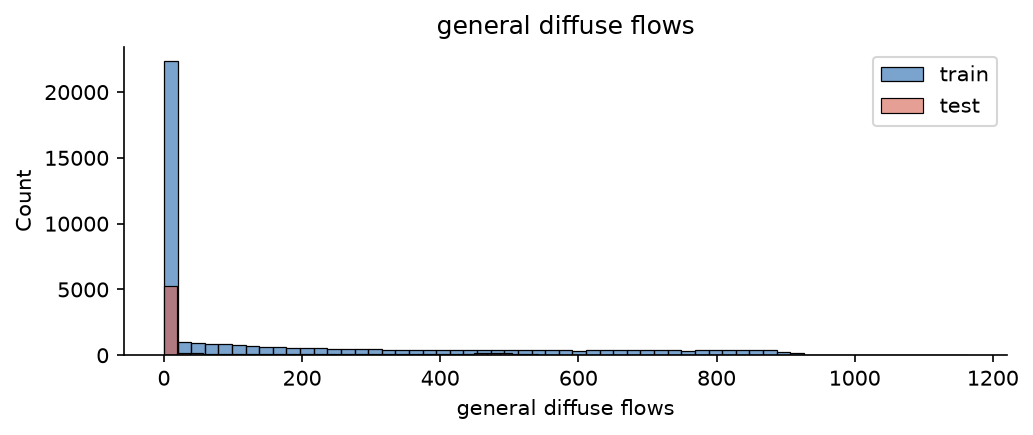

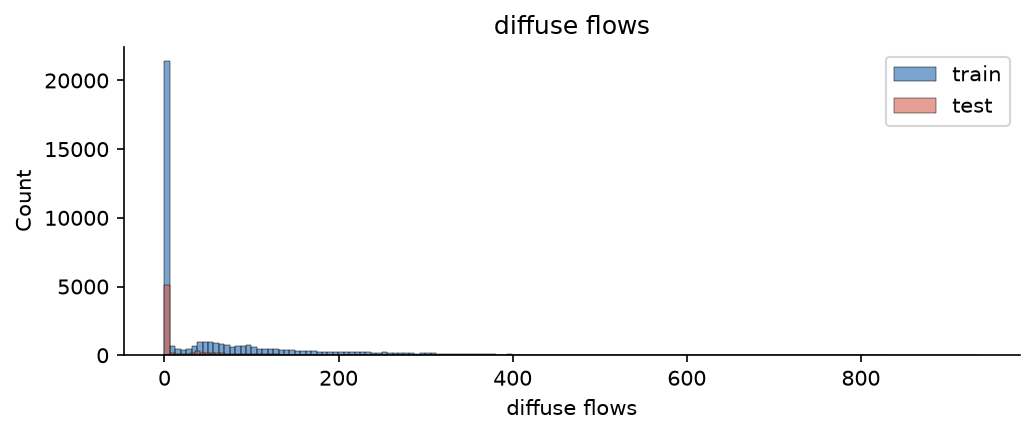

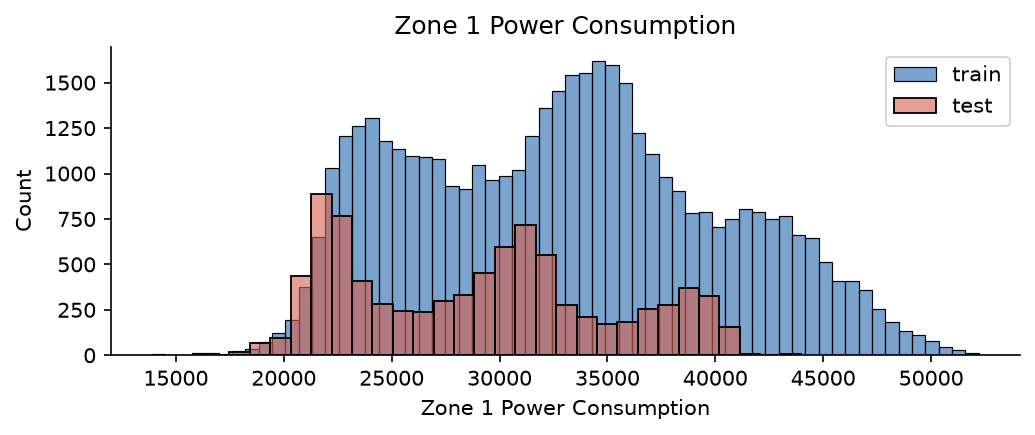

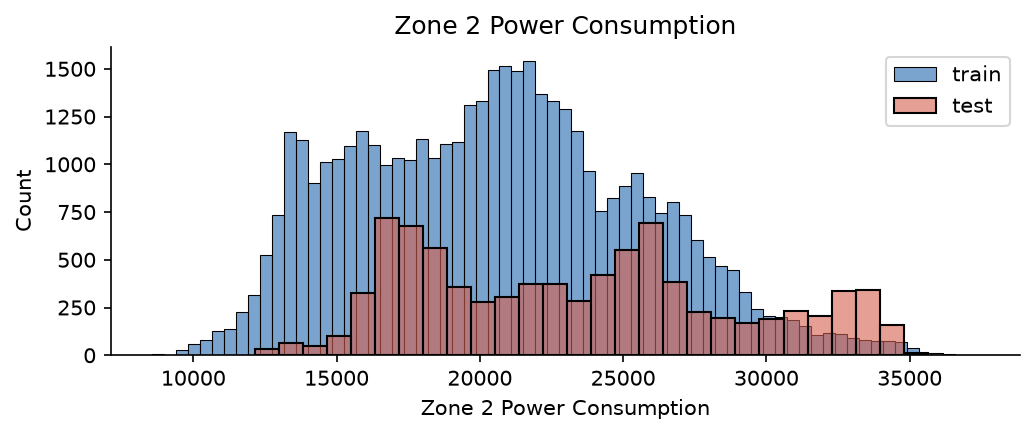

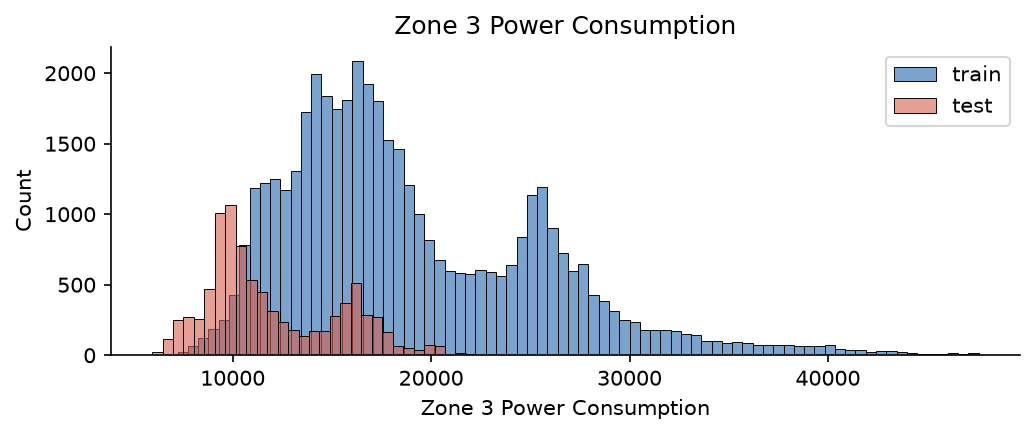

In [7]:
def plot_distribution(feature):
    fig, ax = plt.subplots(figsize=(7, 3))
    sns.histplot(train[feature], ax=ax, color='#2166ac', alpha=0.6, label='train')
    sns.histplot(test[feature],  ax=ax, color='#d6604d', alpha=0.6, label='test')
    ax.set_title(feature)
    ax.legend()
    plt.tight_layout()
    plt.show()

for feature in df.columns:
    plot_distribution(feature)

## 7. Correlation Matrix

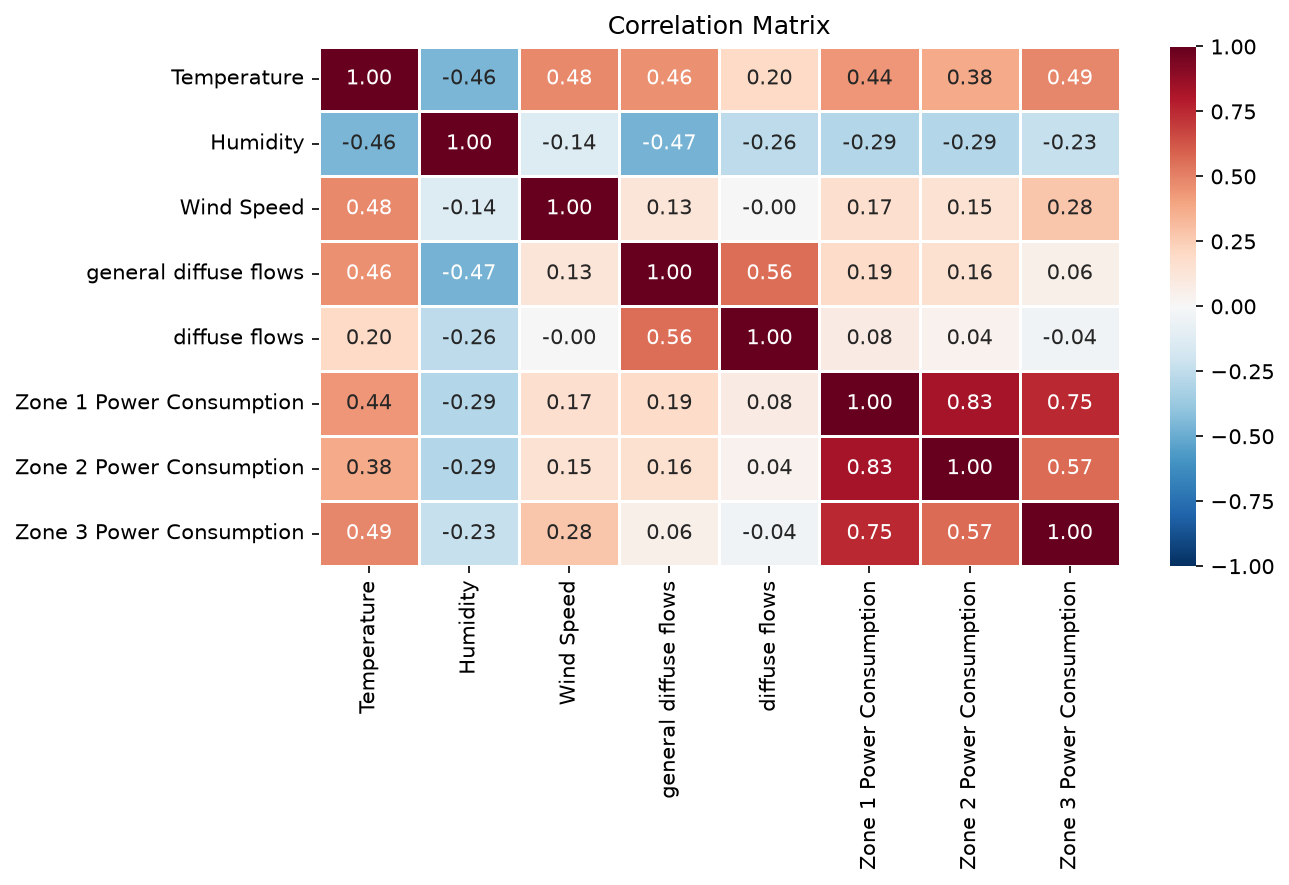

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    df.corr().round(2),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 8. Autocorrelation (ACF / PACF)

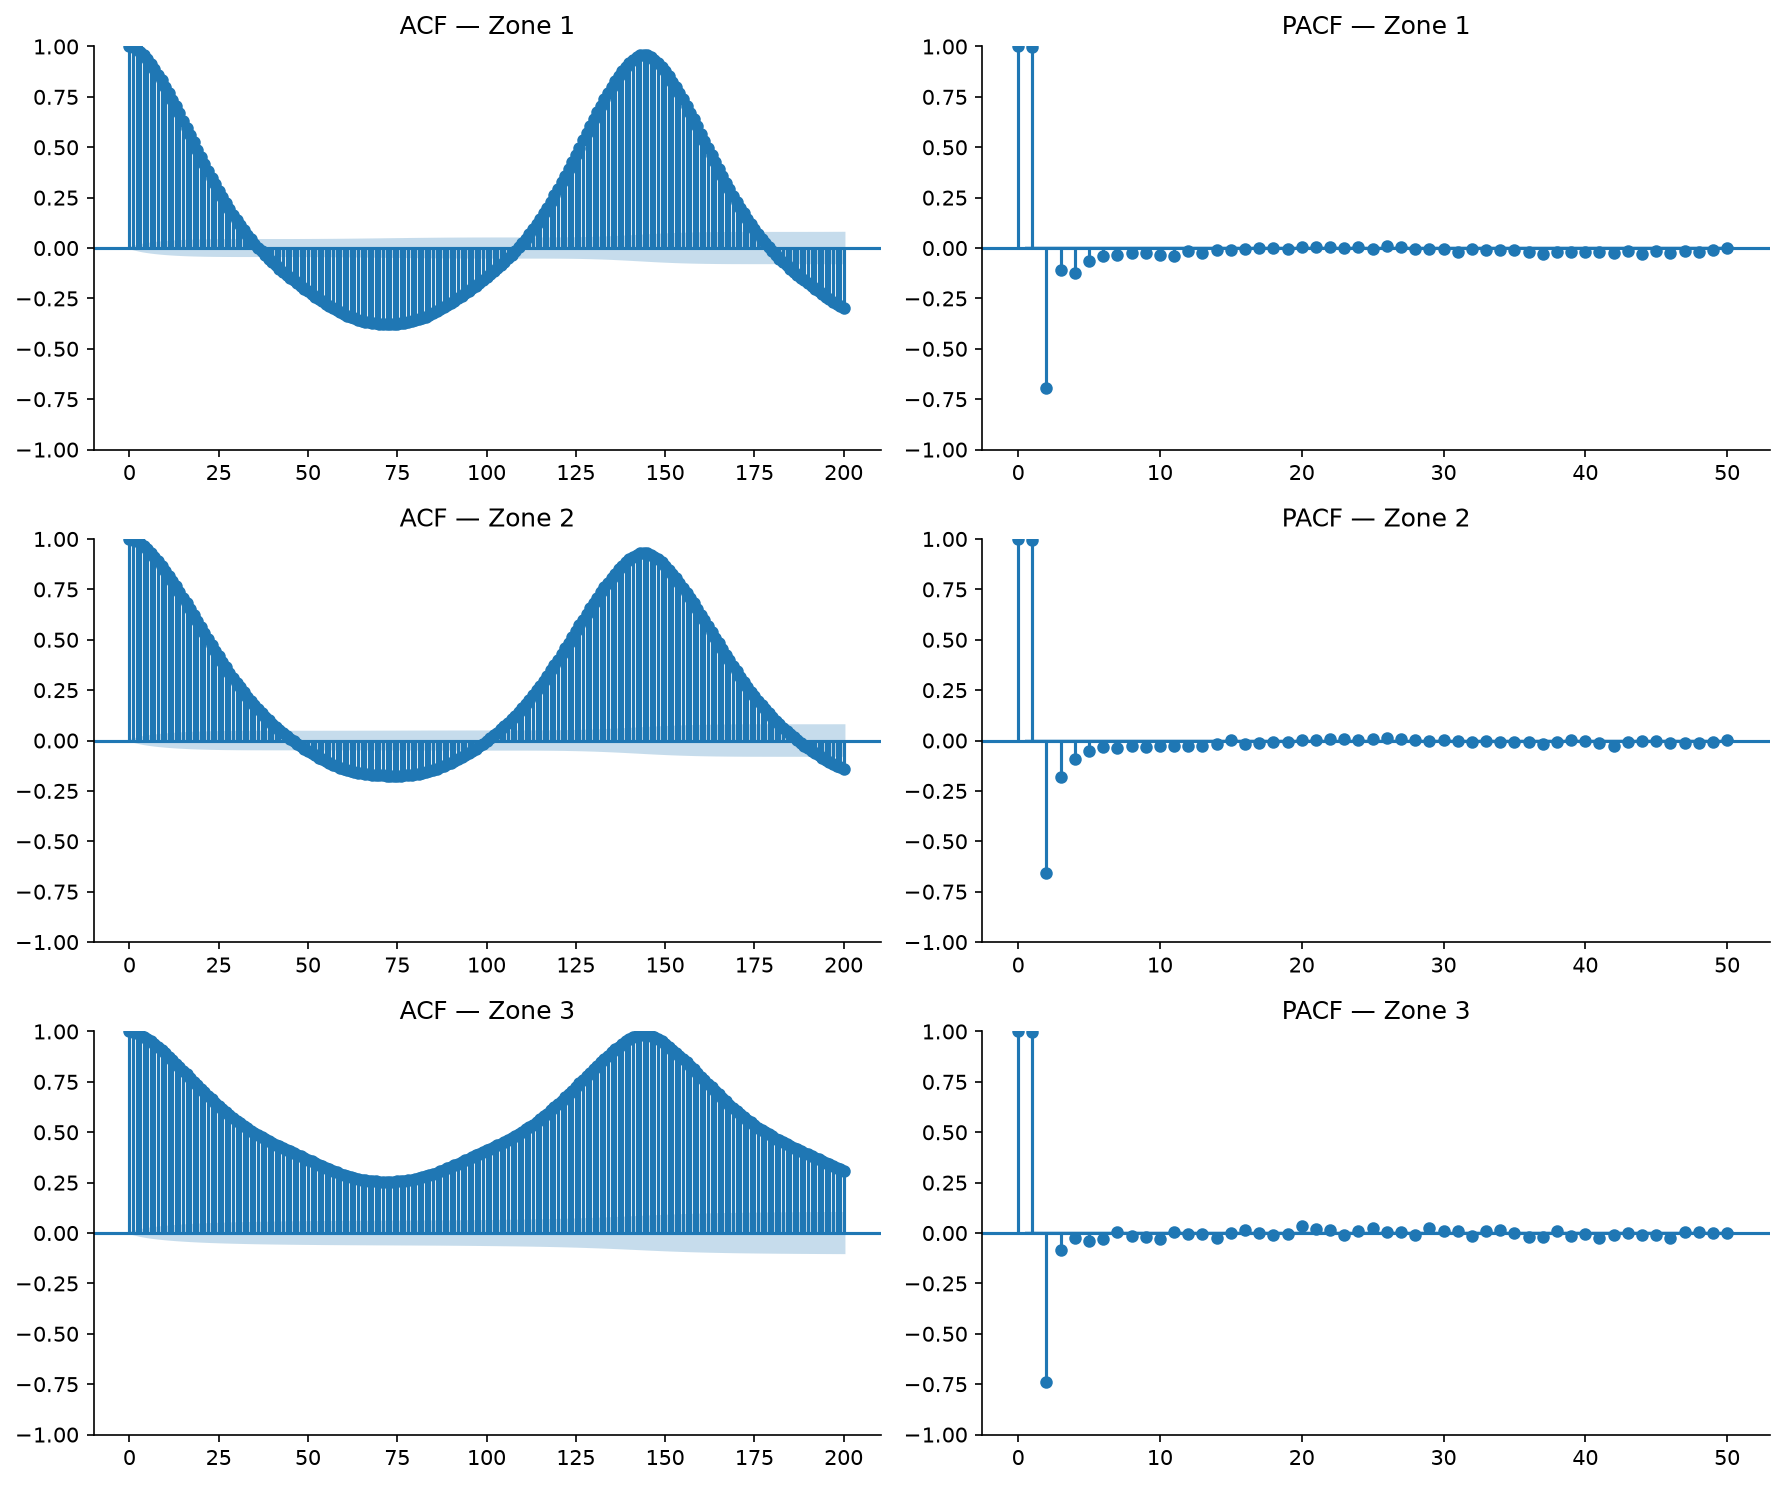

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for i, zone in enumerate(ZONES):
    plot_acf(df[zone], lags=200, ax=axes[i][0], title=f'ACF — {ZONE_LABELS[i]}')
    plot_pacf(df[zone], lags=50, ax=axes[i][1], title=f'PACF — {ZONE_LABELS[i]}', method='ywm')
plt.tight_layout()
plt.show()

## 9. Feature Engineering

In [11]:
def build_features(df, target_col):
    feat = df[WEATHER].copy()

    feat['hour'] = df.index.hour
    feat['weekday'] = df.index.weekday
    feat['month'] = df.index.month
    feat['is_weekend'] = (df.index.weekday >= 5).astype(int)
    feat['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    feat['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    feat['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    feat['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

    target = df[target_col]
    for lag in [1, 2, 144, 1008]:
        feat[f'lag_{lag}'] = target.shift(lag)

    for window in [6, 12, 144]:
        feat[f'roll_mean_{window}'] = target.shift(1).rolling(window).mean()
        feat[f'roll_std_{window}'] = target.shift(1).rolling(window).std()

    feat[target_col] = target
    return feat.dropna()

In [13]:
feat_z1 = build_features(df, ZONES[0])
print(f'Shape: {feat_z1.shape}')
print(feat_z1.columns.tolist())

Shape: (51408, 24)
['Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'hour', 'weekday', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_144', 'lag_1008', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12', 'roll_mean_144', 'roll_std_144', 'Zone 1 Power Consumption']


In [15]:
feat_z2 = build_features(df, ZONES[1])
print(f'Shape: {feat_z2.shape}')

feat_z3 = build_features(df, ZONES[2])
print(f'Shape: {feat_z3.shape}')

Shape: (51408, 24)
Shape: (51408, 24)
